## Check if the packages are installed and all function parameters

In [ ]:
import importlib.util
import sys
import subprocess

def check_installation_and_install(package_name):
    spec = importlib.util.find_spec(package_name)
    if spec is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(package_name + " is installed");

def save_cleaned_csv(dataframe,filename):
    os.makedirs("Cleaned_Data", exist_ok=True)  # Ensures directory exists
    dataframe.to_csv(f"Cleaned_Data/{filename}.csv")

check_installation_and_install("pandas")
check_installation_and_install("matplotlib")
check_installation_and_install("numpy")
check_installation_and_install("seaborn")
check_installation_and_install("scikit-learn")

pandas is installed
matplotlib is installed
numpy is installed
seaborn is installed


## Import Packages

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Insert Dataset to clean and preprocess

In [ ]:
file_directory = "../dataset"

# Load dataset from a CSV file
office_1_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part1.csv"))
office_2_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part2.csv"))
small_apartment_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part3.csv"))
small_workshop_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part4.csv"))
kitchen_livingroom_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part5.csv"))
bed_room_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part6.csv"))
boiler_room_df = pd.read_csv(os.path.join(file_directory,"uwb_dataset_part7.csv"))

df_array = [office_1_df,office_2_df,small_apartment_df,small_workshop_df,kitchen_livingroom_df,bed_room_df,boiler_room_df]

dataset_names = [
    "Office 1", "Office 2", "Small Apartment", "Small Workshop",
    "Kitchen Living Room", "Bedroom", "Boiler Room"
]

for df, name in zip(df_array, dataset_names):
    df['location'] = name

df = pd.concat(df_array)

## Check the data description 

In [5]:
# Generate descriptive statistics of the dataset
df.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,...,257.455357,267.230833,249.123929,225.917143,239.445476,240.034286,254.388095,243.190643,253.173595,90.203429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,...,148.613220,155.703171,132.054825,113.041790,131.519415,133.820366,177.274537,135.598470,145.780909,145.839730
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,56.000000,6727.000000,961.000000,318.00000,...,161.000000,161.000000,161.000000,150.000000,154.000000,154.000000,155.000000,154.000000,158.000000,0.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,68.000000,9950.500000,1134.000000,513.00000,...,233.000000,243.000000,233.000000,217.000000,225.000000,227.000000,229.000000,223.000000,230.000000,0.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,80.000000,12443.000000,1488.000000,1024.00000,...,313.000000,338.000000,304.000000,275.000000,288.000000,292.000000,297.000000,295.000000,308.000000,256.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,324.000000,37208.000000,5169.000000,1056.00000,...,1593.000000,1497.000000,1172.000000,1169.000000,1315.000000,1595.000000,2153.000000,1428.000000,1709.000000,1280.000000


## Removal of Unnecessary Columns

In [6]:
df = df.drop(columns=['CH','PREAM_LEN','BITRATE','PRFR'], axis=1)
# Generate descriptive statistics of the dataset
df.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,...,257.455357,267.230833,249.123929,225.917143,239.445476,240.034286,254.388095,243.190643,253.173595,90.203429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,...,148.613220,155.703171,132.054825,113.041790,131.519415,133.820366,177.274537,135.598470,145.780909,145.839730
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,56.000000,6727.000000,961.000000,318.00000,...,161.000000,161.000000,161.000000,150.000000,154.000000,154.000000,155.000000,154.000000,158.000000,0.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,68.000000,9950.500000,1134.000000,513.00000,...,233.000000,243.000000,233.000000,217.000000,225.000000,227.000000,229.000000,223.000000,230.000000,0.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,80.000000,12443.000000,1488.000000,1024.00000,...,313.000000,338.000000,304.000000,275.000000,288.000000,292.000000,297.000000,295.000000,308.000000,256.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,324.000000,37208.000000,5169.000000,1056.00000,...,1593.000000,1497.000000,1172.000000,1169.000000,1315.000000,1595.000000,2153.000000,1428.000000,1709.000000,1280.000000


## Check Any Missing Value

In [7]:
print(f"DataFrame Missing Values:")
# Check for missing values in the dataset
print(df.isnull().sum().unique())

DataFrame Missing Values:
[0]


## Check for any duplicated values

In [8]:
duplicate = df[df.duplicated()]

if not duplicate.empty:
    print("Duplicate Rows :")
    print(duplicate)
    print("-" * 30)
else:
    print("No duplicate rows found")
    print("-" * 30)

No duplicate rows found
------------------------------


## Check valid data types 

In [9]:
def check_data_types(df):
    print(f"Dataset: {df.dtypes.unique()}")

print("Data Types : {check_data_types(df)}")

float_cols = df.select_dtypes(include=['float64']).columns
object_cols = df.select_dtypes(include=['O']).columns

print("Float64 columns:", float_cols)
print("Object columns:", object_cols)

Data Types : {check_data_types(df)}
Float64 columns: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1027)
Object columns: Index(['location'], dtype='object')


## Feature Importance
After exploring with an list of numbers: 50,100,200.
Best Result is 50

In [ ]:
# Dictionary to store top feature names per dataset
feature_list_names = {}

def explore_feature_random_forest(df,n_features):    
    global feature_list_names  # Ensure we update the global dictionary

    # Separate features and target variable
    X = df.drop(columns=['location','RANGE'], errors='ignore')
    y = df['RANGE']

    # Train Random Forest for exploration
    clf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    # Train the model on the training data
    clf.fit(X, y)

    # Get feature importance
    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
    feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

    # Store top 'n_features' in dictionary with dataset index as key
    feature_list_names = feature_importance.head(n_features)['Feature'].tolist()
    
    # Print results
    print(f"Top {n_features} Important Features:")
    print(feature_importance.head(n_features))

# Example call
explore_feature_random_forest(df, 50)

Top 50 Important Features:
       Feature  Importance
8       RXPACC    0.473865
6      CIR_PWR    0.064394
0         NLOS    0.030729
823     CIR813    0.024911
827     CIR817    0.008444
819     CIR809    0.006980
4      FP_AMP3    0.006707
7    MAX_NOISE    0.006099
3      FP_AMP2    0.005251
831     CIR821    0.005220
820     CIR810    0.005034
821     CIR811    0.004516
818     CIR808    0.004489
817     CIR807    0.003983
813     CIR803    0.003979
2      FP_AMP1    0.003968
829     CIR819    0.003829
814     CIR804    0.003734
815     CIR805    0.003193
816     CIR806    0.002735
825     CIR815    0.002580
1       FP_IDX    0.002471
779     CIR769    0.002432
826     CIR816    0.002328
824     CIR814    0.002156
830     CIR820    0.001941
780     CIR770    0.001830
808     CIR798    0.001801
778     CIR768    0.001725
781     CIR771    0.001663
828     CIR818    0.001651
794     CIR784    0.001604
782     CIR772    0.001600
832     CIR822    0.001596
791     CIR781    0.001498
8

## Repopulate the df_array with the features required

In [11]:
def repopulate_array(df, feature_dict):
    selected_features = set()
    for feature in feature_dict:
        selected_features.add(feature)
    selected_features.add('RANGE')
    selected_features = df.columns.intersection(selected_features)  # Avoid KeyError
    df_filtered = df[selected_features]

    return df_filtered

df_feature_importance = repopulate_array(df,feature_list_names)

# Generate descriptive statistics of the dataset
df_feature_importance.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC,CIR766,...,CIR813,CIR814,CIR815,CIR816,CIR817,CIR818,CIR819,CIR820,CIR821,CIR822
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,9789.690214,1316.096524,616.27250,2738.571786,...,597.935833,589.482000,585.992143,566.568238,543.373476,539.408929,535.461238,525.710119,519.364810,517.223429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,4912.556005,582.434989,306.78537,2400.088904,...,479.504013,468.454426,454.359746,435.194395,422.106828,416.511552,406.092498,396.694662,383.865888,373.921851
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,0.000000,310.000000,128.00000,8.000000,...,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,1.000000,5.000000,2.000000,3.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,6727.000000,961.000000,318.00000,1128.750000,...,286.000000,287.000000,288.000000,278.000000,265.000000,264.000000,264.000000,261.000000,262.000000,267.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,9950.500000,1134.000000,513.00000,2031.000000,...,474.000000,471.000000,473.000000,460.000000,445.000000,442.000000,440.000000,436.000000,436.000000,440.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,12443.000000,1488.000000,1024.00000,3553.250000,...,740.000000,730.000000,732.000000,708.000000,678.000000,679.000000,674.000000,663.000000,659.000000,654.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,37208.000000,5169.000000,1056.00000,23054.000000,...,8254.000000,11166.000000,13069.000000,6387.000000,9788.000000,13981.000000,8508.000000,11664.000000,13592.000000,14099.000000


## Check for Outliers

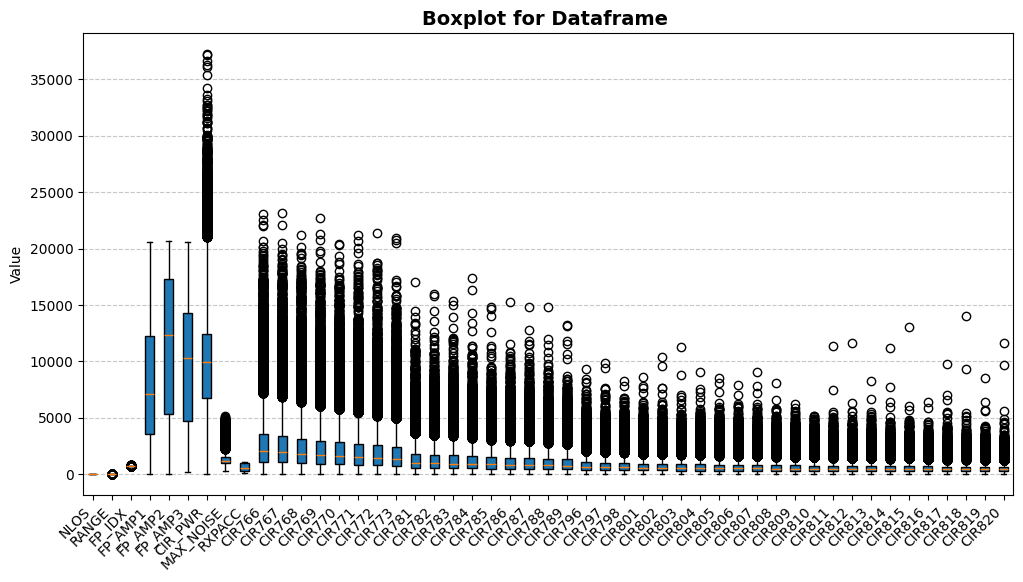

In [12]:
# columns_to_check = [
#     "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
#     "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC",
#     "FRAME_LEN"
# ]

columns_to_check = df_feature_importance.columns[:-2] #Get all columns except the last column
# Plot data for visualization
plt.figure(figsize=(12, 6)) #Create a 12x6 figure for the plot
# Plot data for visualization
plt.boxplot(df_feature_importance[columns_to_check], vert=True, patch_artist=True) #Create a boxplot for columns 


plt.xticks(range(1, len(columns_to_check) + 1), columns_to_check, rotation=45, ha="right") #Configuring x label
# Plot data for visualization
plt.title(f"Boxplot for Dataframe ", fontsize=14, fontweight="bold") #Add a title
plt.ylabel("Value") #Add y label
# Plot data for visualization
plt.grid(axis='y', linestyle='--', alpha=0.7) #Add grid to the plot

plt.show()

## Remove Outliers

In [13]:
#Outliers are removed using Z Score
def calculate_mean(column):
    return sum(column) / len(column)

def calculate_std(column, mean):
    if len(column) < 2:
        return 0
    variance = sum((x - mean) ** 2 for x in column) / len(column) #Average Squared difference from the mean
    return variance ** 0.5 

def remove_outliers(df,columns, threshold=3):
    for col in columns:
        if col in df.columns:
# Drop rows with missing values
            column_data = df[col].dropna().tolist() #Converting to list

            mean = calculate_mean(column_data) #Calculate mean for column
            std = calculate_std(column_data, mean) #Calculate STD for column

            #Filter rows where absolute Z score is less than threshold
            #Rows that has zScore greater or equal to threshold are removed as they will be considered outlier
            df_filtered_rows = df[[abs((x - mean)/ std) < threshold if not pd.isna(x) else False for x in df[col]]] 
            
    return df_filtered_rows

df_feature_importance = remove_outliers(df_feature_importance, columns_to_check)

df_feature_importance.shape

(41215, 51)

## Check after outliners removal 

In [14]:
# Generate descriptive statistics of the dataset
df_feature_importance.describe()

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC,CIR766,...,CIR813,CIR814,CIR815,CIR816,CIR817,CIR818,CIR819,CIR820,CIR821,CIR822
count,41215.000000,41215.000000,41215.0000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,...,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000,41215.000000
mean,0.496809,3.794884,745.6321,8153.871333,11465.409899,9767.573311,9674.460755,1315.735242,613.272862,2682.172219,...,583.346743,575.072935,571.661677,553.770496,530.335703,526.030790,514.474876,495.009729,499.683635,506.017979
std,0.499996,2.343742,4.4407,5408.454299,6247.349647,5362.194036,4804.770773,579.900444,307.042578,2333.634738,...,458.150668,445.554215,429.407603,415.855965,399.442058,389.888932,363.576948,320.660510,340.152063,350.293638
min,0.000000,0.000000,707.0000,7.000000,63.000000,187.000000,0.000000,310.000000,128.000000,8.000000,...,4.000000,3.000000,1.000000,2.000000,2.000000,2.000000,1.000000,5.000000,2.000000,3.000000
25%,0.000000,1.790000,744.0000,3576.000000,5333.500000,4729.500000,6662.500000,960.000000,316.000000,1116.000000,...,283.000000,284.000000,285.000000,275.000000,263.000000,262.000000,261.000000,258.000000,259.000000,265.000000
50%,0.000000,3.440000,746.0000,7164.000000,12435.000000,10320.000000,9897.000000,1135.000000,505.000000,2003.000000,...,469.000000,466.000000,468.000000,455.000000,440.000000,437.000000,435.000000,430.000000,429.000000,436.000000
75%,1.000000,5.350000,748.0000,12340.500000,17336.000000,14295.000000,12340.500000,1489.000000,1024.000000,3482.000000,...,725.000000,716.500000,718.000000,694.000000,664.000000,666.000000,656.000000,643.000000,641.000000,642.000000
max,1.000000,28.020000,848.0000,20572.000000,20624.000000,20577.000000,37208.000000,5169.000000,1056.000000,23054.000000,...,8254.000000,7717.000000,5713.000000,4659.000000,5526.000000,5149.000000,4237.000000,1712.000000,3212.000000,3961.000000


## Checking Covariance (How Two Variables Vary Together Through a linear relationship)

DataFrame


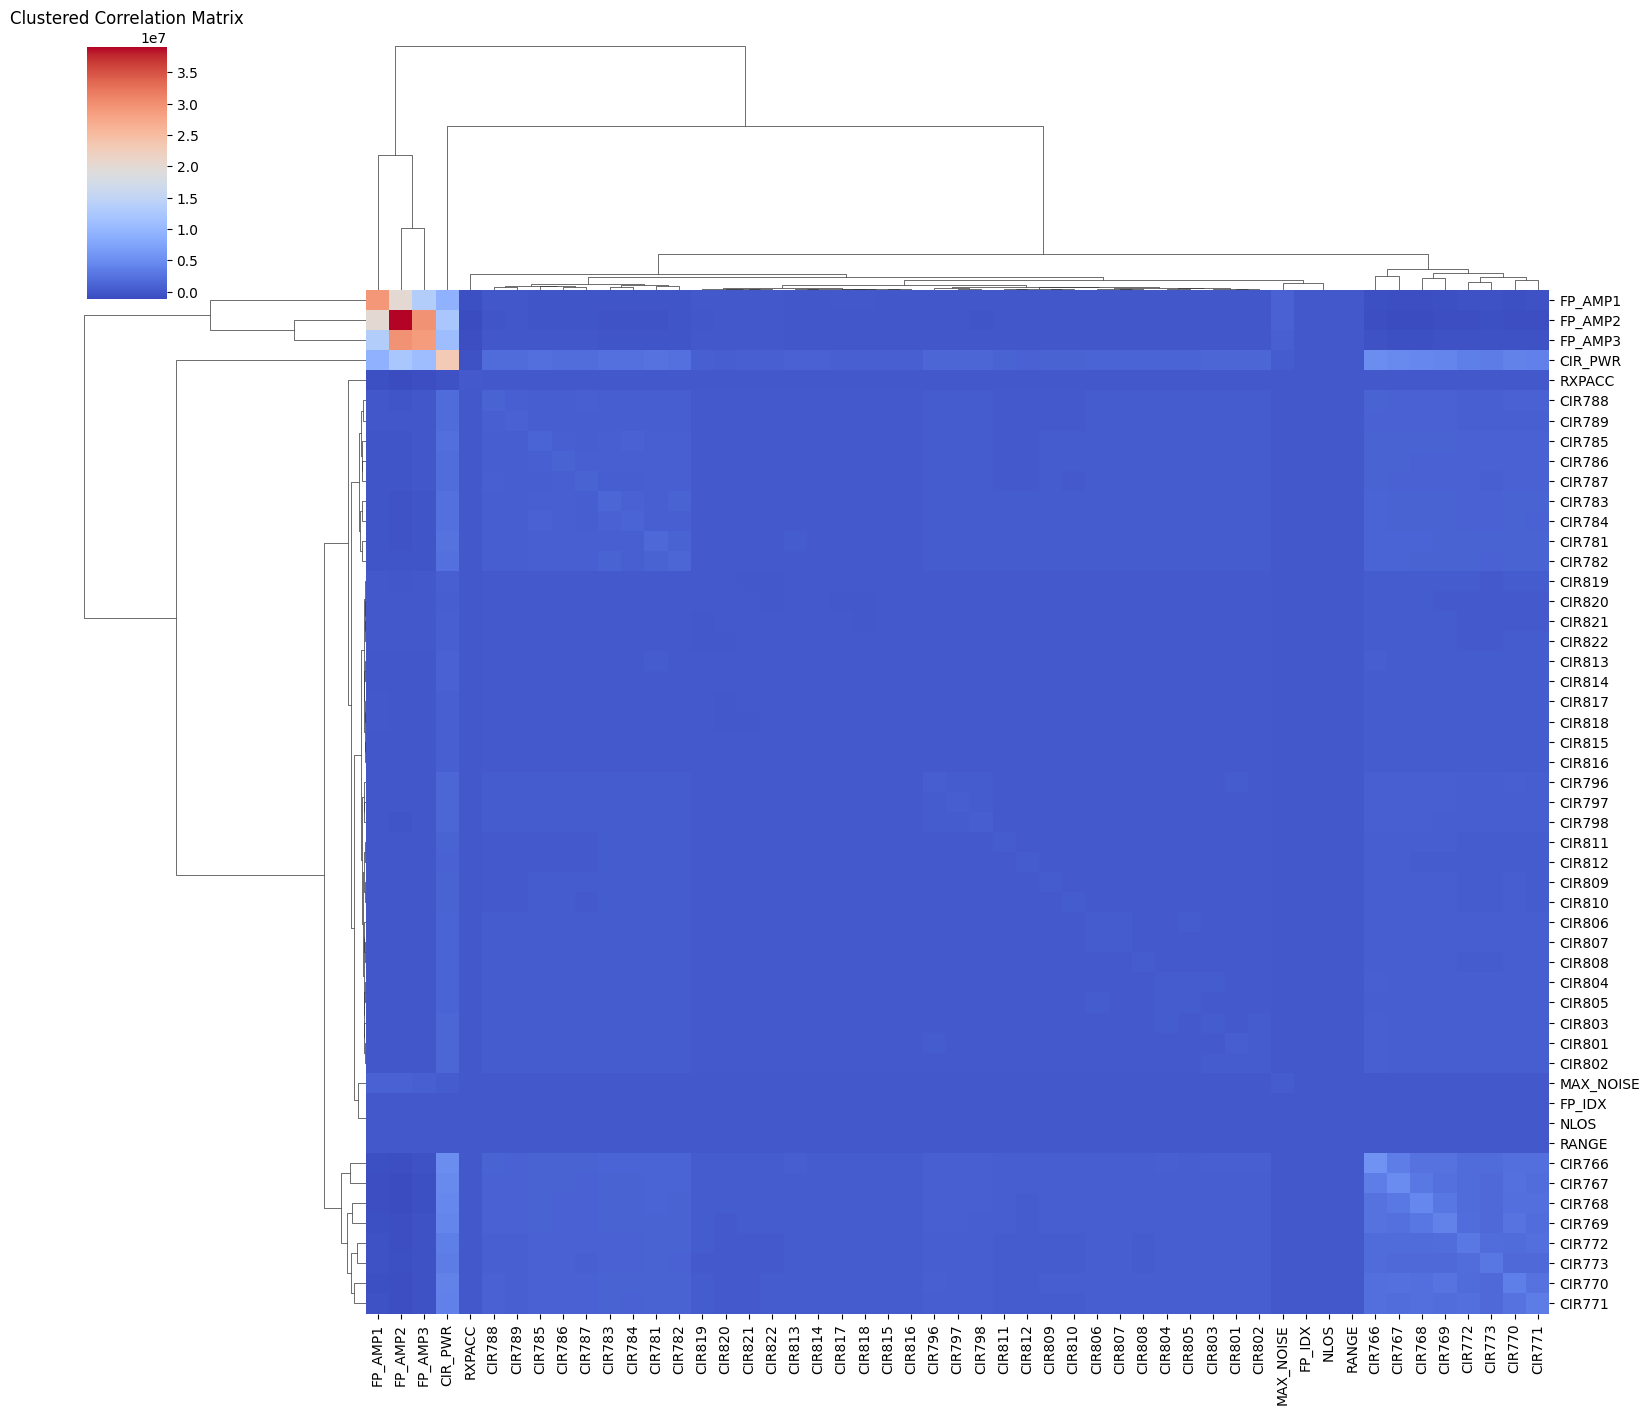

--------------------------------------------------


In [15]:
cov_matrix = df_feature_importance.cov()

print(f"DataFrame")
sns.clustermap(cov_matrix,  cmap="coolwarm", figsize=(16, 14))
plt.title("Clustered Correlation Matrix")
plt.show()
print("-" * 50)

## Checking Correlation (Strength & Direction of Relationships)

DataFrame


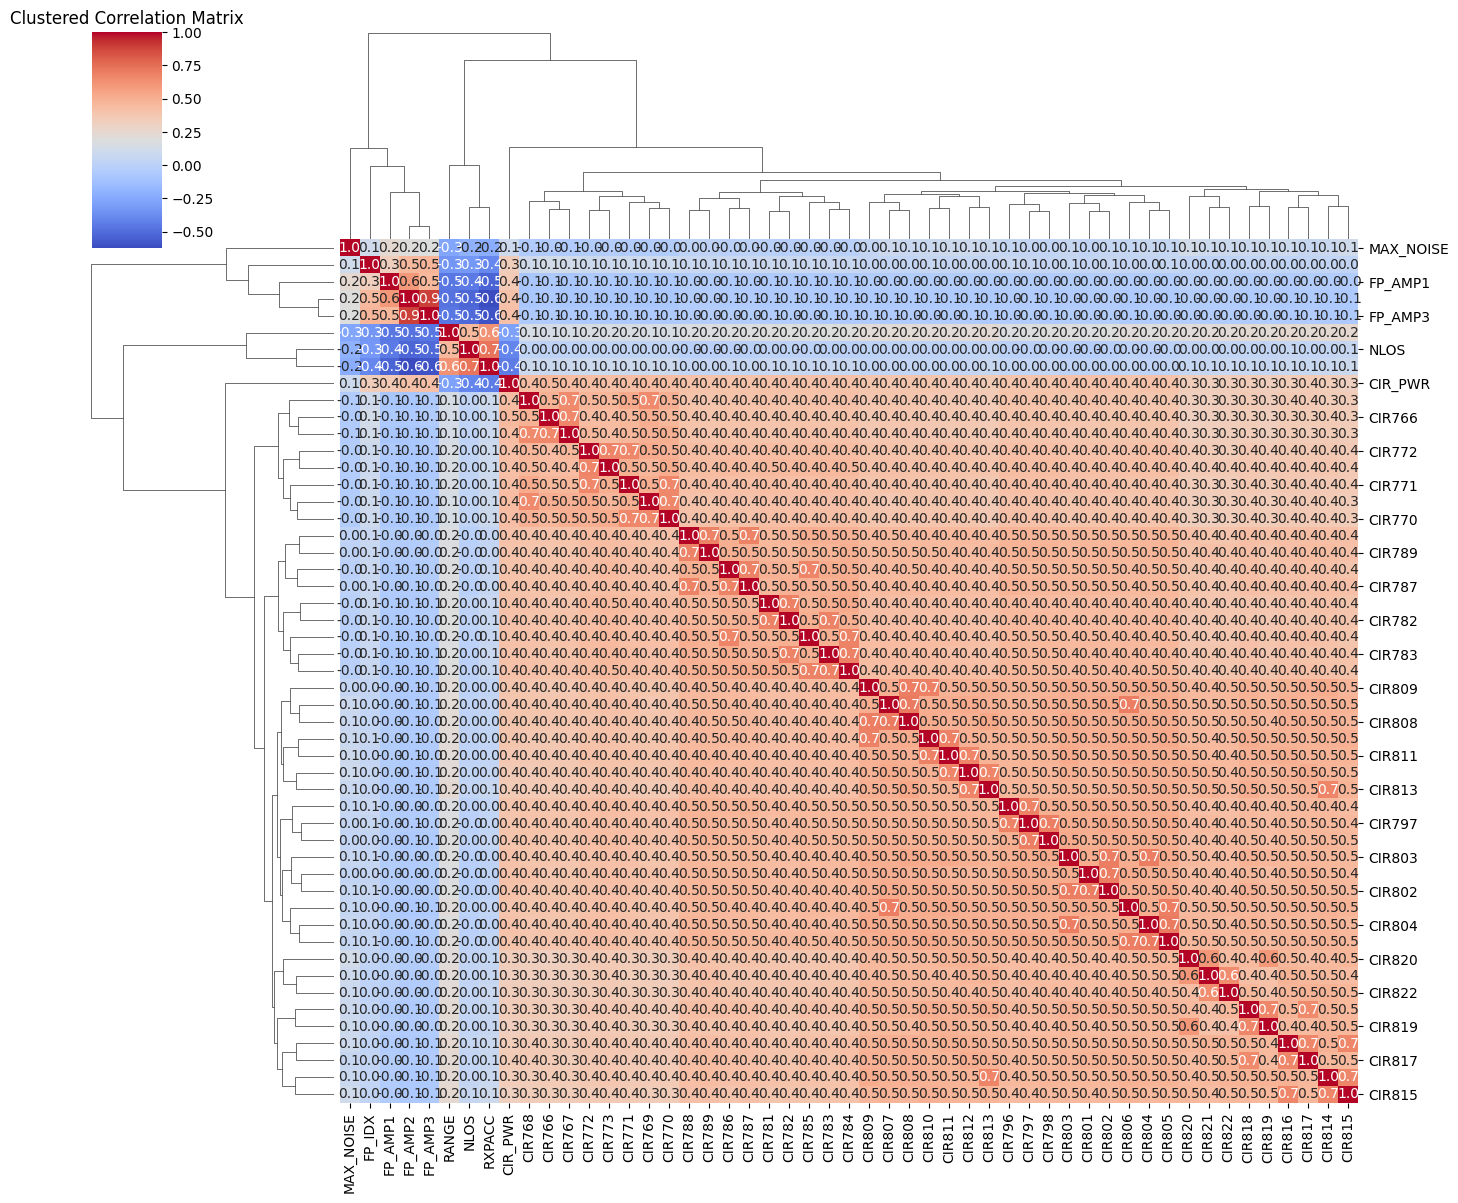

--------------------------------------------------


In [16]:
corr_matrix = df_feature_importance.corr()
print(f"DataFrame")

sns.clustermap(corr_matrix, annot=True, cmap="coolwarm", fmt=".1f", figsize=(14, 12))
plt.title("Clustered Correlation Matrix")
plt.show()
print("-" * 50)

## Do Principal Component Analysis 


Dataset

Transformed DataFrame after PCA:


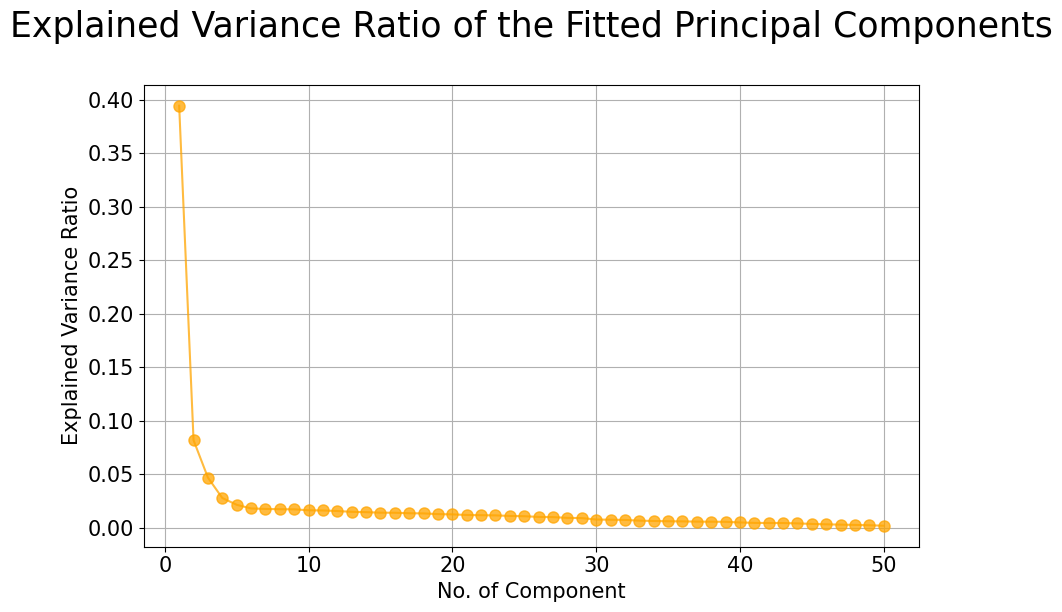

In [ ]:
#Standardize the Data
dfx = {}

print(f"\nDataset")

X = df_feature_importance.drop('RANGE',axis=1)
y = df_feature_importance['RANGE']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Standardize the Data
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)

#Store standardized data
dfx = pd.DataFrame(data=X_train_scaled ,columns=X.columns)

print("\nTransformed DataFrame after PCA:")

#Apply PCA
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
# Plot data for visualization
plt.plot([i+1 for i in range(len(pca.explained_variance_ratio_))],
         pca.explained_variance_ratio_,
         marker='o', linestyle='-', color='orange', markersize=8, alpha=0.75)
plt.grid(True)
plt.title("Explained Variance Ratio of the Fitted Principal Components\n", fontsize=25)
plt.yticks(fontsize=15)
plt.ylabel("Explained Variance Ratio", fontsize=15)
plt.xticks(fontsize=15)
plt.xlabel("No. of Component", fontsize=15)

plt.show()

#Find minimum number of components that explain 95% of variance
# explained_variance = np.cumsum(pca.explained_variance_ratio_)
# n_components = 

# 0.001 is added to avoid floating point error

### Dropping data that are < 0.015

In [30]:

df_clean = {}
used_features = set() 
dominant_features = []

print(f"\nProcessing PCA for: Dataset")

# Perform PCA without limiting components
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(dfx)

explained_variance = pca.explained_variance_ratio_

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Find the number of components that explain at least 95% of the variance
n_components_to_keep = np.argmax(cumulative_variance >= 0.95) + 1

# Select the components up to the 95% threshold
selected_components = np.arange(n_components_to_keep)

# Apply the filter to the PCA-transformed data
X_train_pca_filtered = X_train_pca[:, selected_components]

# Calculate feature contributions
feature_contributions = np.abs(pca.components_)  

original_features = dfx.columns 

for i in selected_components:
    contributions = feature_contributions[i].copy() 
    for idx, feature in enumerate(original_features):
        if feature in used_features:
            contributions[idx] = -np.inf  

    max_index = np.argmax(contributions) 
    chosen_feature = original_features[max_index]

    dominant_features.append(chosen_feature)
    used_features.add(chosen_feature)

pca_column_labels = [f"{feature}" for feature in dominant_features]

# Create a DataFrame with the selected features
df_pca = pd.DataFrame(data=df, columns=pca_column_labels)

df_clean = df_pca

print("\nFiltered PCA DataFrame:")
# Generate descriptive statistics of the dataset
df_clean.describe()


Processing PCA for: Dataset

Filtered PCA DataFrame:


,CIR805,FP_AMP2,CIR769,CIR783,CIR802,MAX_NOISE,CIR772,CIR821,CIR818,CIR814,...,CIR771,CIR786,CIR767,CIR801,CIR819,CIR782,CIR_PWR,CIR820,CIR808,CIR766
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,703.821810,11425.259524,2307.387643,1307.401119,736.976405,1316.096524,1997.668143,519.364810,539.408929,589.482000,...,2100.916714,1162.967452,2614.493000,746.731452,535.461238,1336.652333,9789.690214,525.710119,668.682857,2738.571786
std,608.383098,6235.434769,2065.860745,1162.803323,631.384544,582.434989,1806.913949,383.865888,416.511552,468.454426,...,1878.527991,1032.017774,2287.816521,642.997057,406.092498,1186.971683,4912.556005,396.694662,565.030428,2400.088904
min,1.000000,63.000000,7.000000,6.000000,2.000000,310.000000,4.000000,2.000000,2.000000,3.000000,...,8.000000,4.000000,10.000000,4.000000,1.000000,2.000000,0.000000,5.000000,3.000000,8.000000
25%,319.000000,5322.750000,944.000000,536.000000,335.000000,961.000000,812.000000,262.000000,264.000000,287.000000,...,859.000000,486.000000,1070.000000,337.000000,264.000000,551.000000,6727.000000,261.000000,308.000000,1128.750000
50%,519.000000,12318.000000,1685.000000,949.000000,545.000000,1134.000000,1448.000000,436.000000,442.000000,471.000000,...,1539.000000,848.000000,1949.000000,550.000000,440.000000,970.000000,9950.500000,436.000000,502.000000,2031.000000
75%,854.000000,17310.000000,2975.000000,1693.000000,915.000000,1488.000000,2562.000000,659.000000,679.000000,730.000000,...,2704.000000,1486.000000,3394.000000,921.250000,674.000000,1715.000000,12443.000000,663.000000,811.250000,3553.250000
max,8494.000000,20624.000000,22703.000000,15355.000000,10389.000000,5169.000000,21398.000000,13592.000000,13981.000000,11166.000000,...,21164.000000,15262.000000,23148.000000,8622.000000,8508.000000,15972.000000,37208.000000,11664.000000,8059.000000,23054.000000


### Testing accuracy


In [ ]:
df_accuracy = {}

print(f"\nEvaluating Accuracy for:Dataset")

original_df = df

X = original_df.drop(['RANGE','location'], axis=1)
y = original_df['RANGE']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=df_pca.shape[1])  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model = LinearRegression()
# Train the model on the training data
model.fit(X_train_pca, y_train)

# Make predictions using the trained model
y_train_pred = model.predict(X_train_pca)
y_test_pred = model.predict(X_test_pca)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nFinal Accuracy Table:")
print(f"Train R2 Score: {train_r2}")
print(f"Test R2 Score: {test_r2}")


Evaluating Accuracy for:Dataset

Final Accuracy Table:
Train R2 Score: 0.5151496848966157
Test R2 Score: 0.5063122921344675


In [32]:

df_clean = df_clean.drop(columns=[col for col in ['index', 'level_0', 'location'] if col in df_clean.columns])

# Generate descriptive statistics of the dataset
print(df_clean.describe())

print("")

# Generate descriptive statistics of the dataset
print(df.describe())

df_clean = df_clean.reset_index(drop=True) 
df_clean = df_clean.loc[~df_clean.index.duplicated()]  

for col in ['RANGE', 'NLOS']:
    if col not in df_clean.columns and col in df.columns:
        df_clean[col] = df[col].values  

print("\nFinal Cleaned DataFrame:")
# Display the first few rows of the dataset
print(df_clean.head())

save_cleaned_csv(df_clean, "Range_Cleaned_Data")

             CIR805       FP_AMP2        CIR769        CIR783        CIR802  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.000000   
mean     703.821810  11425.259524   2307.387643   1307.401119    736.976405   
std      608.383098   6235.434769   2065.860745   1162.803323    631.384544   
min        1.000000     63.000000      7.000000      6.000000      2.000000   
25%      319.000000   5322.750000    944.000000    536.000000    335.000000   
50%      519.000000  12318.000000   1685.000000    949.000000    545.000000   
75%      854.000000  17310.000000   2975.000000   1693.000000    915.000000   
max     8494.000000  20624.000000  22703.000000  15355.000000  10389.000000   

          MAX_NOISE        CIR772        CIR821        CIR818        CIR814  \
count  42000.000000  42000.000000  42000.000000  42000.000000  42000.000000   
mean    1316.096524   1997.668143    519.364810    539.408929    589.482000   
std      582.434989   1806.913949    383.865888    